In [2]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & ACADEMIC AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean narrative output.
#          2. Connect to the Golden Master DB (pienza.db).
#          3. Apply the "Opus Academic" Visual Canon for LaTeX integration.
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None

# --- 2. CORE IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# --- 3. CONNECTIVITY ---
print("⏳ Mounting environment and connecting to DB...")
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive Mounted.")
except:
    print("ℹ️ Running locally or Drive already mounted.")

DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db' # Adjust if needed

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"✅ SQL Engine Active: {DB_PATH}")

# --- 4. VISUAL CANON (OPUS ACADEMIC THEME) ---
# Strictly optimized for LaTeX: Pure white backgrounds, sharp contrast.
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_ORANGE = '#fde725'
OPUS_DARK   = '#121212'
OPUS_MUTED  = '#7A7A7A'

sns.set_theme(style="white") # No grids by default
plt.rcParams.update({
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor': '#FFFFFF',
    'text.color': OPUS_DARK,
    'xtick.color': OPUS_DARK,
    'ytick.color': OPUS_DARK,
    'axes.edgecolor': '#E0E0E0',
    'axes.linewidth': 1.0,
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_DARK,
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.titlesize': 16,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Academic (LaTeX Ready).")
print("\n--- PHASE 5 ENVIRONMENT READY ---")

⏳ Mounting environment and connecting to DB...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive Mounted.
✅ SQL Engine Active: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ Visual Identity Loaded: Opus Academic (LaTeX Ready).

--- PHASE 5 ENVIRONMENT READY ---


In [5]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [6]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================
import pandas as pd
from IPython.display import display

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Polygon Consolidation)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'),
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [7]:
# ==============================================================================
# CELL 1.3: MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================
import numpy as np
from IPython.display import display

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


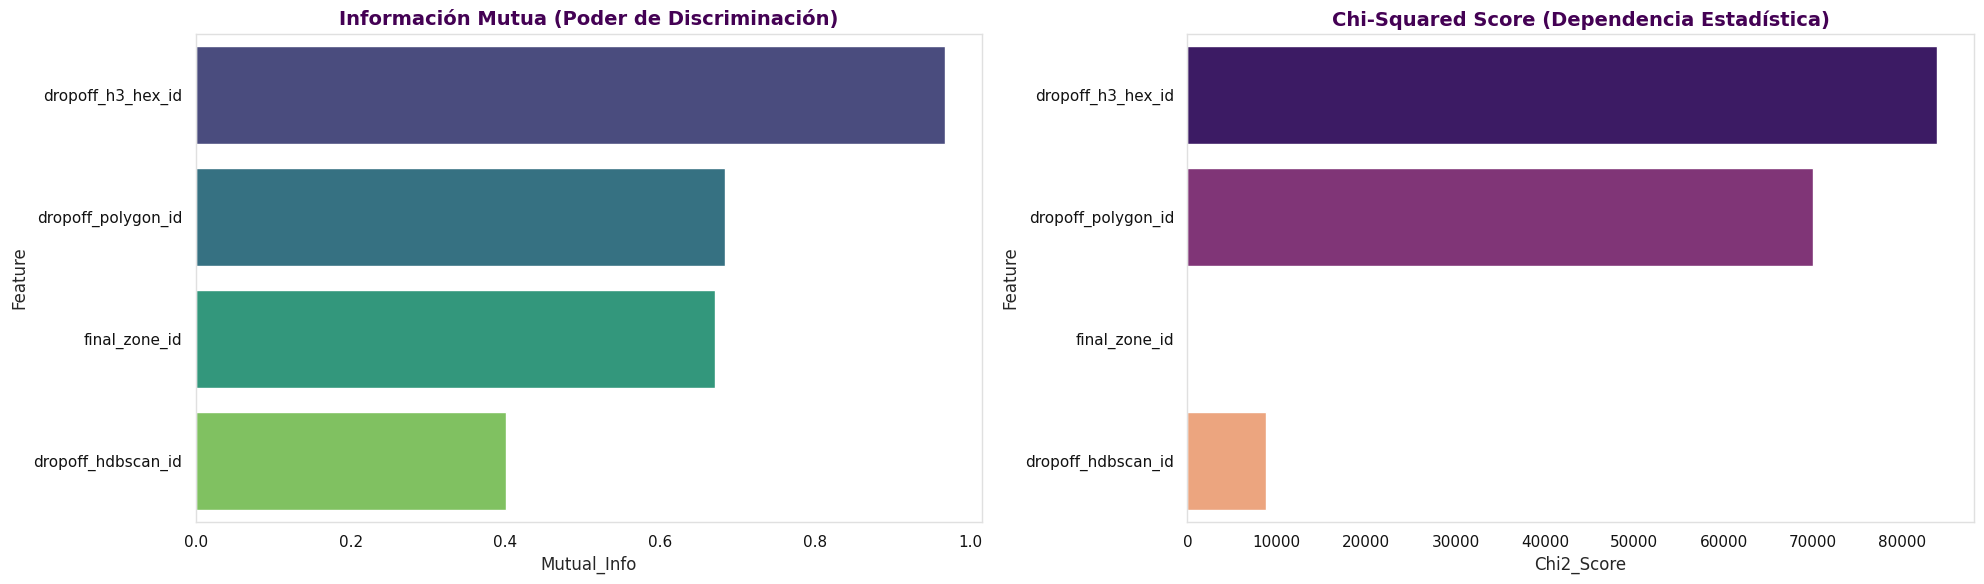

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [8]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color='#440154')

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color='#440154')

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

⏳ Engineering Temporal Features & Initiating Rematch...


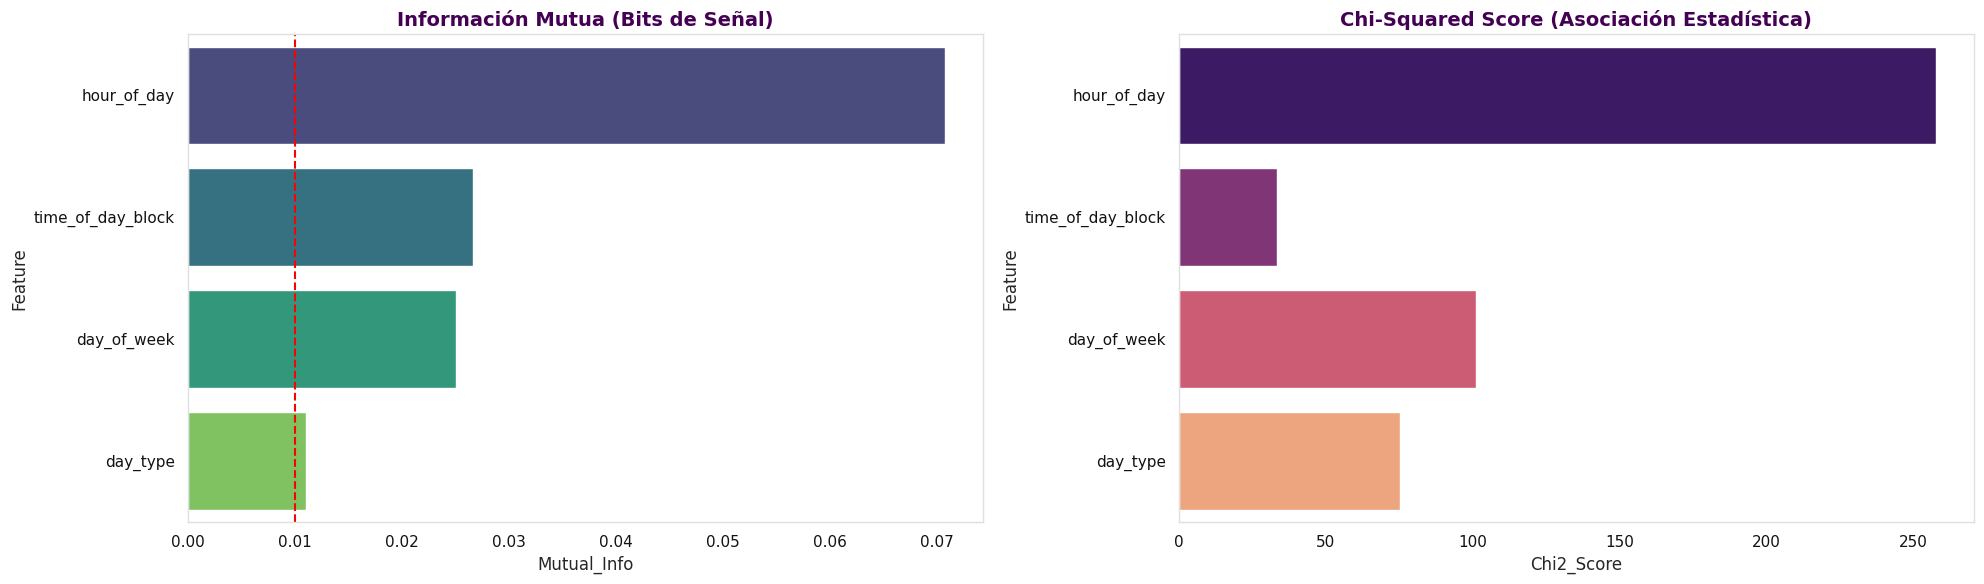

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
2,time_of_day_block,0.026592,33.587240,8.081494e-06
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.011012,75.211573,3.472007e-14



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada.


In [11]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Create temporal features and audit them to select the most informative.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Engineering Temporal Features & Initiating Rematch...")

# --- 0. FEATURE ENGINEERING (Creación de las dimensiones) ---
# Nos aseguramos de que el timestamp sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 1. Granularidad Horaria
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour

# 2. Granularidad Diaria
df_input['day_of_week'] = df_input['offer_timestamp'].dt.day_name()

# 3. Abstracción Humana (Bloques)
def assign_day_block(h):
    if 6 <= h < 10: return 'Morning_Rush'
    elif 10 <= h < 15: return 'Midday_Base'
    elif 15 <= h < 20: return 'Evening_Rush'
    else: return 'Night_Ops'
df_input['time_of_day_block'] = df_input['hour_of_day'].apply(assign_day_block)

# 4. Abstracción Simple (Tipo de día)
df_input['day_type'] = np.where(df_input['offer_timestamp'].dt.dayofweek < 5, 'Weekday', 'Weekend')


# --- 1. DEFINICIÓN DE CONTENDIENTES ---
time_competitors = [
    'hour_of_day',      # 0-23
    'day_of_week',      # Mon-Sun
    'time_of_day_block',# Semantic Blocks
    'day_type'          # Weekday/Weekend
]

# --- 2. CODIFICACIÓN TEMPORAL ---
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# --- 3. CÁLCULO DE MÉTRICAS ---
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# --- 4. CONSOLIDACIÓN DE INTELIGENCIA ---
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# --- 5. VISUALIZACIÓN DUAL ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color='#440154')
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color='#440154')

plt.tight_layout()
plt.show()

# --- 6. REPORTE TÉCNICO ---
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada.
"""))

⏳ Auditing 3 features in isolation...


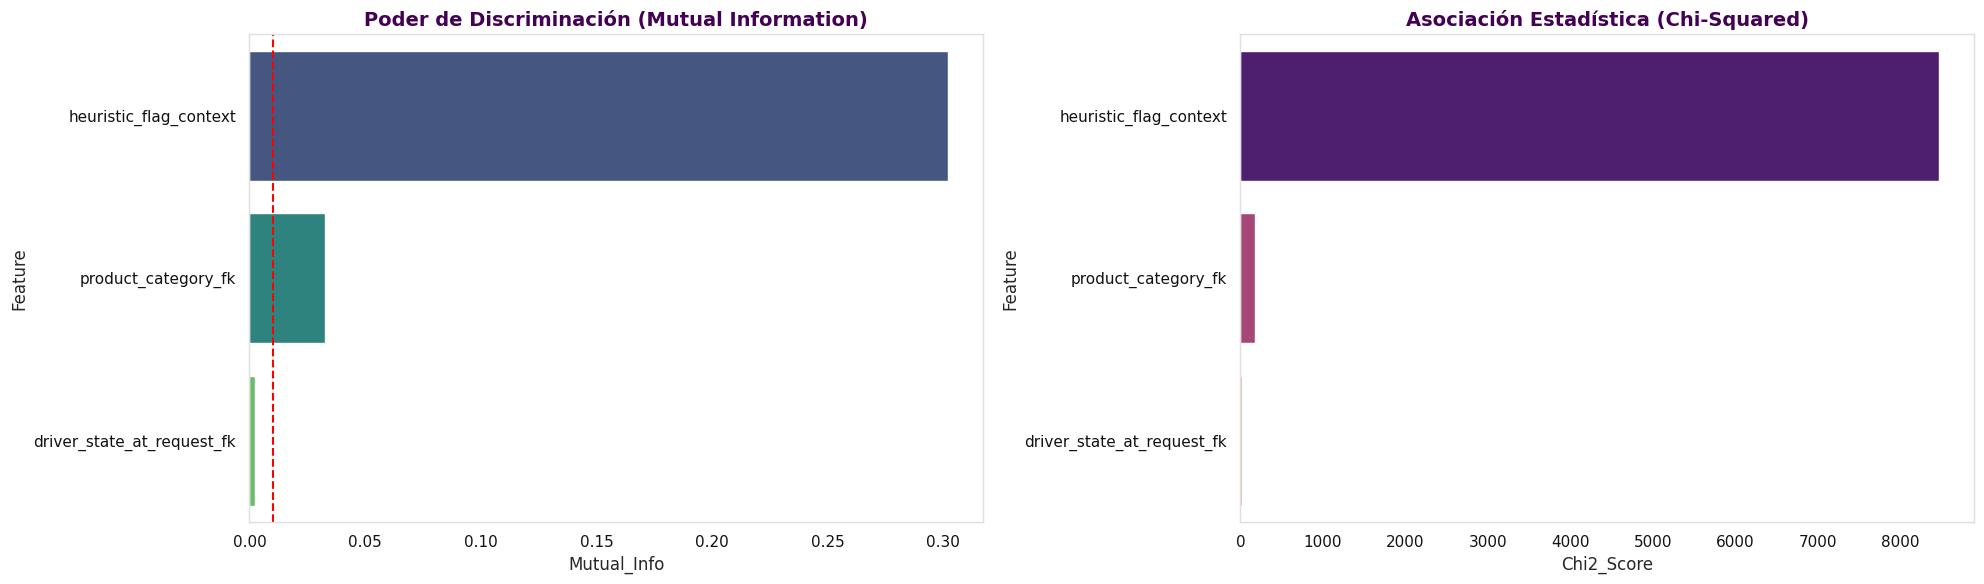

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,heuristic_flag_context,0.302027,8471.929880,0.000000e+00
1,product_category_fk,0.032699,182.354377,1.072798e-36
2,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.3020**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [9]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color='#440154')
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color='#440154')

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

# Usamos iloc de forma segura asumiendo que heuristic_flag_context quedó en primer lugar
mi_ganador = df_solo_audit.iloc[0]['Mutual_Info'] if not df_solo_audit.empty else 0

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{mi_ganador:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

⏳ calculating forensic signals (mi + chi2)...


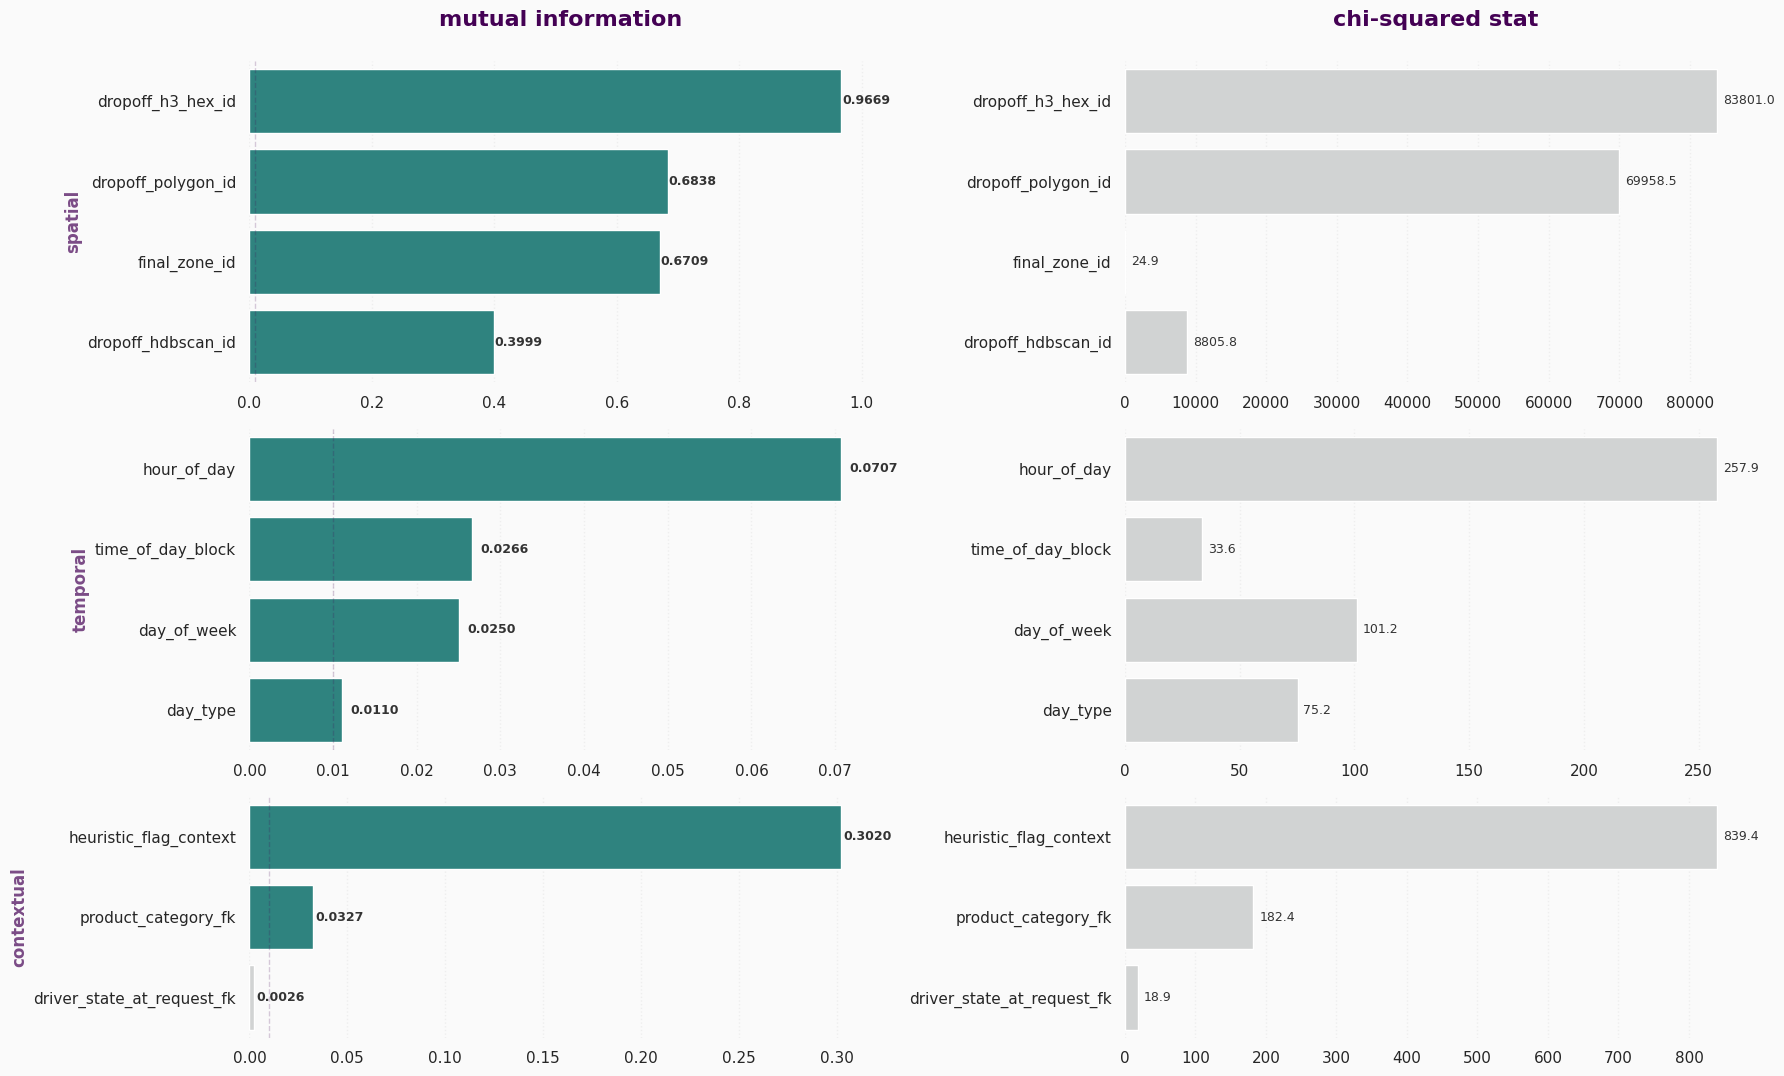

📊 summary: 10 survivors kept, 1 noise variables purged.


In [24]:
# ==============================================================================
# CELL 1.4 (PIENZA FINAL): THE CATEGORICAL FOUNDRY & ARENA (CLEAN LABELS)
# ==============================================================================
# Purpose: Dual-metric forensic audit with uniform bar thickness and clean labels.
# Final Tweaks: Removed 'arena' suffix and renamed context to contextual.
# ==============================================================================

from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. PIENZA CANONICAL COLORS (SOBER)
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"   # survivor (signal)
PIENZA_GRAY = "#D0D3D4"   # noise / chi2 column (neutral)
PIENZA_PURPLE = "#440154" # structure
PIENZA_TEXT = "#333333"

# --- STEP 2: MULTIVARIATE AUDIT (THE TOURNAMENT) ---
print("⏳ calculating forensic signals (mi + chi2)...")
arenas = {
    'spatial_arena':  ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id'],
    'temporal_arena': ['hour_of_day', 'day_of_week', 'time_of_day_block', 'day_type'],
    'context_arena':  ['heuristic_flag_context', 'product_category_fk', 'driver_state_at_request_fk']
}

results_list = []
for arena_name, features in arenas.items():
    for col in features:
        if col in df_input.columns:
            x_encoded = LabelEncoder().fit_transform(df_input[col].fillna("n/a").astype(str)).reshape(-1, 1)
            mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]
            c2_stat, _ = chi2(x_encoded, y)
            results_list.append({
                'Arena': arena_name, 'Feature': col, 'MI': mi, 'Chi2': c2_stat[0],
                'Status': 'survivor' if mi >= 0.01 else 'noise'
            })
df_results = pd.DataFrame(results_list)

# --- STEP 3: VISUALIZACIÓN CLÍNICA (UNIFORM BARS & CONTEXTUAL LABELS) ---
# Gridspec handles uniform pixel height for bars across 4-4-3 distributions.
fig, axes = plt.subplots(3, 2, figsize=(18, 12), facecolor=PIENZA_BG,
                         gridspec_kw={'height_ratios': [4, 4, 3]})

colors_mi = {'survivor': PIENZA_TEAL, 'noise': PIENZA_GRAY}
color_chi = PIENZA_GRAY

for i, (arena_name, row_axes) in enumerate(zip(arenas.keys(), axes)):
    subset = df_results[df_results['Arena'] == arena_name].sort_values('MI', ascending=False)

    # --- COL 0: MUTUAL INFORMATION ---
    ax_mi = row_axes[0]
    ax_mi.set_facecolor(PIENZA_BG)
    sns.barplot(data=subset, x='MI', y='Feature', hue='Status', palette=colors_mi, ax=ax_mi, dodge=False, width=0.8, legend=False)
    ax_mi.axvline(0.01, color=PIENZA_PURPLE, linestyle='--', alpha=0.2, linewidth=1)

    for p in ax_mi.patches:
        val = p.get_width()
        if val > 0.0001:
            ax_mi.text(val + 0.001, p.get_y() + p.get_height()/2, f'{val:.4f}', va='center', fontsize=9, fontweight='bold', color=PIENZA_TEXT)

    # --- COL 1: CHI-SQUARED ---
    ax_c2 = row_axes[1]
    ax_c2.set_facecolor(PIENZA_BG)
    sns.barplot(data=subset, x='Chi2', y='Feature', color=color_chi, ax=ax_c2, width=0.8)

    for p in ax_c2.patches:
        val = p.get_width()
        if val > 0.1:
            ax_c2.text(val + (subset['Chi2'].max()*0.01), p.get_y() + p.get_height()/2, f'{val:.1f}', va='center', fontsize=9, color=PIENZA_TEXT)

    # --- ROW & COLUMN STYLING ---
    for j, ax in enumerate(row_axes):
        if i == 0:
            ax.set_title(f"{'mutual information' if j==0 else 'chi-squared stat'}",
                         fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=25)

        # Label Refinement: Delete 'arena' and rename 'context' -> 'contextual'
        if j == 0:
            clean_label = arena_name.replace('_arena', '').replace('context', 'contextual')
            ax.set_ylabel(clean_label, fontsize=12, fontweight='bold', color=PIENZA_PURPLE, alpha=0.7)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        if ax.get_legend(): ax.get_legend().remove()
        sns.despine(left=True, bottom=True, ax=ax)
        ax.grid(axis='x', color='#DDDDDD', linestyle=':', alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

# Final Summary
noise_list = df_results[df_results['Status'] == 'noise']['Feature'].tolist()
print(f"📊 summary: {len(df_results) - len(noise_list)} survivors kept, {len(noise_list)} noise variables purged.")